In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/Wallet.csv')
print(df.head())
print(df.shape)

X = df.drop('wallet',axis=1)
y = df['wallet']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=6721
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

   wallet  male  business  punish  explain
0       2     0         0       2        0
1       2     0         0       2        1
2       3     0         0       1        1
3       3     0         0       2        0
4       1     1         0       1        1
(195, 5)
Train size: 146
Test size: 49


------------------Your name and student ID------------------------
Name:  Saebyeok Chu Student ID:  40356395

--- Train Set ---
Accuracy  = 0.6918
Precision = 0.6812
Recall    = 0.5241
F1        = 0.5424

--- Test Set ---
Accuracy  = 0.5510
Precision = 0.2780
Recall    = 0.3629
F1        = 0.3148


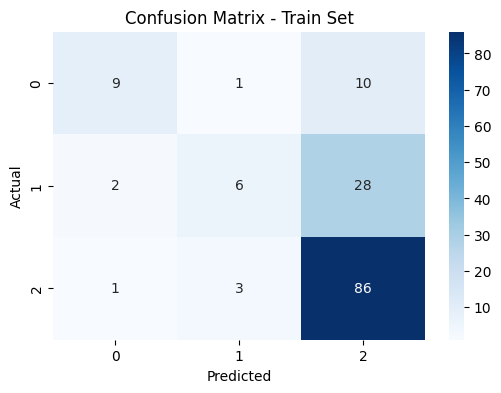

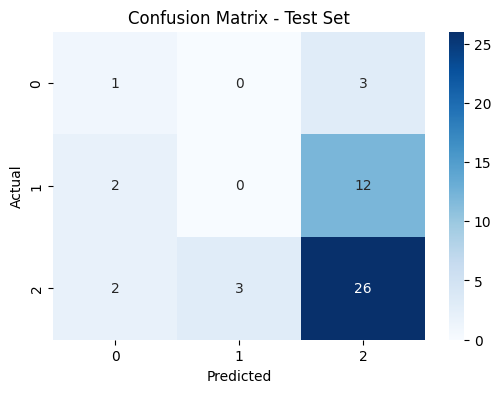

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("------------------Your name and student ID------------------------")
print("Name: ", "Saebyeok Chu", "Student ID: ", "40356395")


rfc = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=6721
)

rfc.fit(X_train, y_train)

y_pred_train = rfc.predict(X_train)
y_pred_test = rfc.predict(X_test)

print("\n--- Train Set ---")
print(f"Accuracy  = {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision = {precision_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")
print(f"Recall    = {recall_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")
print(f"F1        = {f1_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")

print("\n--- Test Set ---")
print(f"Accuracy  = {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")
print(f"F1        = {f1_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")

# Confusion matrices
for y_true, y_pred, set_name in [(y_train, y_pred_train, "Train"), (y_test, y_pred_test, "Test")]:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {set_name} Set")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [14]:
print("------------------Your name and student ID------------------------")
print("Name: ", "Saebyeok Chu", "Student ID: ", "40356395")

results = []

for max_features in [1, 2, 4]:
    rfc = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        max_features=max_features,
    )
    rfc.fit(X_train, y_train)

    y_pred_train = rfc.predict(X_train)
    y_pred_test = rfc.predict(X_test)

    print(f"\n{'='*50}")
    print(f"max_features={max_features}")
    print(f"{'='*50}")
    print(f"--- Train Set ---")
    print(f"Accuracy  = {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Precision = {precision_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")
    print(f"Recall    = {recall_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")
    print(f"F1        = {f1_score(y_train, y_pred_train, average='macro', zero_division=0):.4f}")
    print(f"--- Test Set ---")
    print(f"Accuracy  = {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Precision = {precision_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")
    print(f"Recall    = {recall_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")
    print(f"F1        = {f1_score(y_test, y_pred_test, average='macro', zero_division=0):.4f}")

    results.append({
        'max_features': str(max_features),
        'train_acc': accuracy_score(y_train, y_pred_train),
        'test_acc': accuracy_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train, average='macro', zero_division=0),
        'test_f1': f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    })

------------------Your name and student ID------------------------
Name:  Saebyeok Chu Student ID:  40356395

max_features=1
--- Train Set ---
Accuracy  = 0.6918
Precision = 0.6440
Recall    = 0.5759
F1        = 0.5650
--- Test Set ---
Accuracy  = 0.5714
Precision = 0.3485
Recall    = 0.3867
F1        = 0.3506

max_features=2
--- Train Set ---
Accuracy  = 0.6918
Precision = 0.6860
Recall    = 0.5444
F1        = 0.5430
--- Test Set ---
Accuracy  = 0.5714
Precision = 0.3233
Recall    = 0.4462
F1        = 0.3724

max_features=4
--- Train Set ---
Accuracy  = 0.6918
Precision = 0.6421
Recall    = 0.5667
F1        = 0.5796
--- Test Set ---
Accuracy  = 0.5510
Precision = 0.2833
Recall    = 0.3629
F1        = 0.3182


------------------Your name and student ID------------------------
Name:  Saebyeok Chu Student ID:  40356395

Feature Importance:
1. punish = 0.3770
2. explain = 0.2161
3. business = 0.2051
4. male = 0.2017


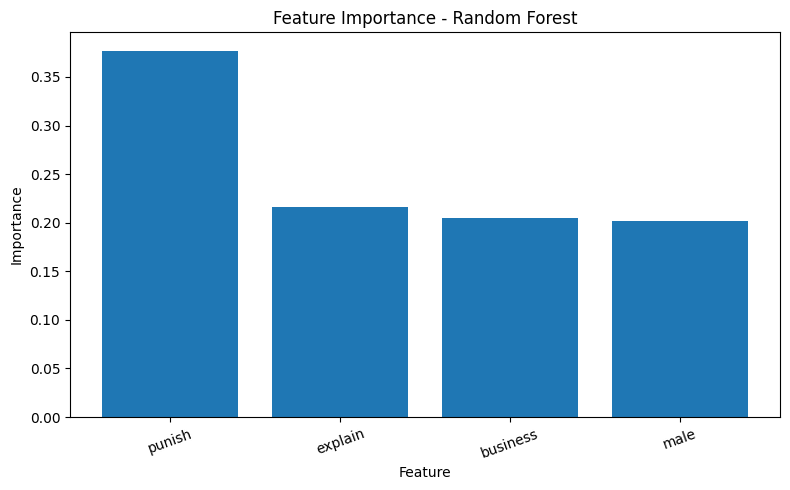

In [16]:
import numpy as np
import matplotlib.pyplot as plt

print("------------------Your name and student ID------------------------")
print("Name: ", "Saebyeok Chu", "Student ID: ", "40356395")

# Feature importance
feature_names = X_train.columns
importances = rfc.feature_importances_

indices = np.argsort(importances)[::-1]

print("\nFeature Importance:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]} = {importances[idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[idx] for idx in indices], rotation=20)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()